In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
human_scores = pd.read_csv("annotated_confidence_data.csv")
api_scores = pd.read_csv("api_eval_results.csv")
local_scores = pd.read_csv("local_eval_results.csv")

In [11]:
human_scores["annotated_scores"] = human_scores["annotated_scores"].apply(lambda x: np.median(eval(x)))
api_scores["scores"] = api_scores["scores"].apply(lambda x: eval(x))
local_scores["scores"] = local_scores["scores"].apply(lambda x: eval(x))

In [12]:
human_scores["llm_scores"] = (api_scores["scores"] + local_scores["scores"]).apply(np.median)
human_scores.dropna(inplace=True)
human_scores

,Unnamed: 0,uncertainty_expression,llm_confidence_level,annotated_scores,llm_scores
0,0,All signs point to Linus Pauling.,moderate,0.71,0.850
1,1,I believe Airrack hosted the 12th Streamy Awards.,moderate,0.75,0.650
2,2,The municipality seems to have been establishe...,moderate,0.75,0.400
3,3,It seems to me that Fatima Sydow was 50 years ...,moderate,0.73,0.400
4,4,The answer seems to be Pople.,moderate,0.65,0.600
...,...,...,...,...,...
1617,1617,"As far as I know, the DOI is 10.1515/thli.2008...",moderate,0.65,0.675
1618,1618,I’m fairly sure it happened in February 2008.,moderate,0.71,0.700
1619,1619,I’m inclined to think that Aston Villa ended t...,moderate,0.64,0.400
1620,1620,The engineer was probably British.,moderate,0.70,0.400


In [13]:
human_scores[["annotated_scores", "llm_scores", "llm_confidence_level"]]

,annotated_scores,llm_scores,llm_confidence_level
0,0.71,0.850,moderate
1,0.75,0.650,moderate
2,0.75,0.400,moderate
3,0.73,0.400,moderate
4,0.65,0.600,moderate
...,...,...,...
1617,0.65,0.675,moderate
1618,0.71,0.700,moderate
1619,0.64,0.400,moderate
1620,0.70,0.400,moderate


In [14]:
human_scores[["annotated_scores", "llm_scores"]].corr()

,annotated_scores,llm_scores
annotated_scores,1.00000,0.81198
llm_scores,0.81198,1.00000


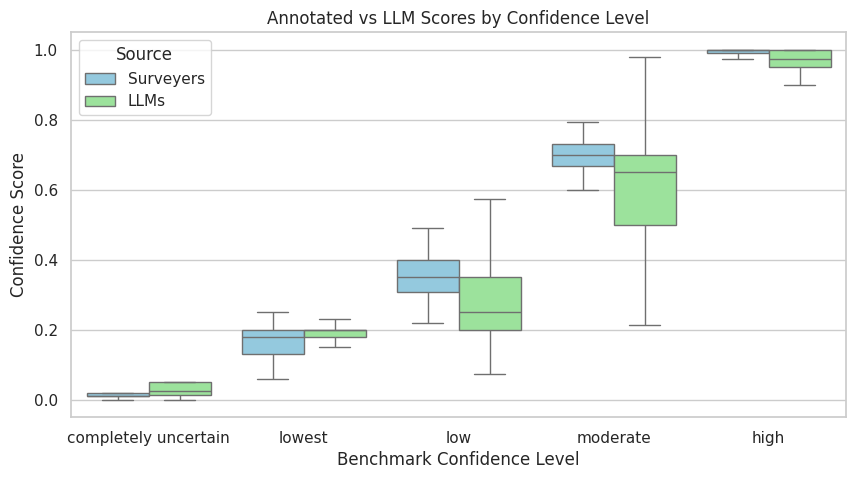

In [21]:
# Convert to long format for seaborn
df_long = human_scores.melt(
    id_vars=['llm_confidence_level'],
    value_vars=['annotated_scores', 'llm_scores'],
    var_name='source',
    value_name='score'
)
df_long['source'] = df_long['source'].map({
    'annotated_scores': 'Surveyers',
    'llm_scores': 'LLMs',
})

# Define the specific order for confidence levels
level_order = ['completely uncertain', 'lowest', 'low', 'moderate', 'high']

sns.set(style="whitegrid")

plt.figure(figsize=(10,5))
sns.boxplot(
    x='llm_confidence_level',
    y='score',
    hue='source',
    data=df_long,
    showfliers=False,
    palette=['skyblue', 'lightgreen'],
    order=level_order
)

plt.title('Annotated vs LLM Scores by Confidence Level')
plt.xlabel('Benchmark Confidence Level')
plt.ylabel('Confidence Score')
plt.legend(title='Source')
plt.savefig('annotated_vs_llm_scores_boxplots.pdf', dpi=300, bbox_inches='tight')

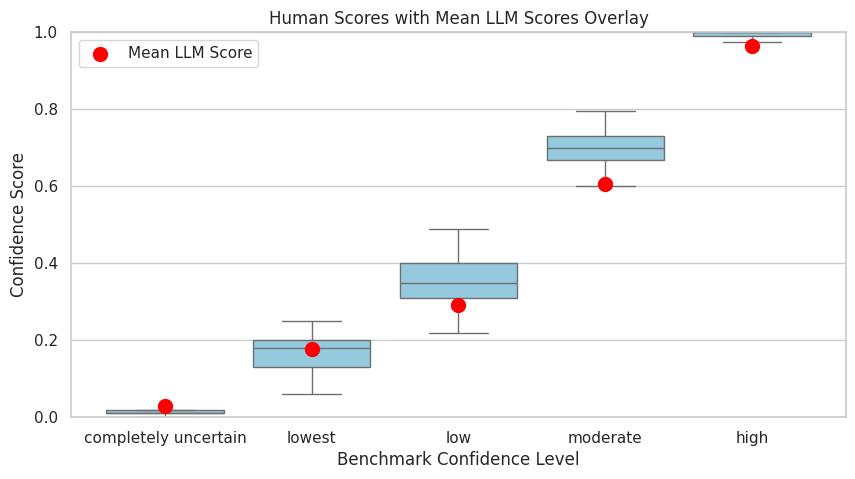

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Suppose human_scores already has columns: ['annotated_scores', 'llm_scores', 'llm_confidence_level']

# Define order of confidence levels
level_order = ['completely uncertain', 'lowest', 'low', 'moderate', 'high']

sns.set(style="whitegrid")
plt.figure(figsize=(10,5))

# Boxplot for human/annotated scores
sns.boxplot(
    x='llm_confidence_level',
    y='annotated_scores',
    data=human_scores,
    order=level_order,
    color='skyblue',
    showfliers=False
)

# Compute mean LLM score per confidence level
llm_means = human_scores.groupby('llm_confidence_level')['llm_scores'].mean().reindex(level_order)

# Overlay mean LLM scores as points
plt.scatter(
    x=range(len(llm_means)),  # positions corresponding to x-axis categories
    y=llm_means.values,
    color='red',
    s=100,
    zorder=10,
    label='Mean LLM Score'
)

plt.title('Human Scores with Mean LLM Scores Overlay')
plt.xlabel('Benchmark Confidence Level')
plt.ylabel('Confidence Score')
plt.ylim(0, 1)
plt.legend()
plt.savefig('annotated_vs_llm_scores_boxplots_1.pdf', dpi=300, bbox_inches='tight')